In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
df = pd.read_excel("epl_final.xlsx")
df.head()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,36757,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,36757,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,36757,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,36757,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,36757,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0


Dataset shape: (9380, 22)
Columns: ['Season', 'MatchDate', 'HomeTeam', 'AwayTeam', 'FullTimeHomeGoals', 'FullTimeAwayGoals', 'FullTimeResult', 'HalfTimeHomeGoals', 'HalfTimeAwayGoals', 'HalfTimeResult', 'HomeShots', 'AwayShots', 'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners', 'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards', 'HomeRedCards', 'AwayRedCards']

Data types:
Season                 str
MatchDate            int64
HomeTeam               str
AwayTeam               str
FullTimeHomeGoals    int64
FullTimeAwayGoals    int64
FullTimeResult         str
HalfTimeHomeGoals    int64
HalfTimeAwayGoals    int64
HalfTimeResult         str
HomeShots            int64
AwayShots            int64
HomeShotsOnTarget    int64
AwayShotsOnTarget    int64
HomeCorners          int64
AwayCorners          int64
HomeFouls            int64
AwayFouls            int64
HomeYellowCards      int64
AwayYellowCards      int64
HomeRedCards         int64
AwayRedCards         in

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,36757,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,36757,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,36757,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,36757,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,36757,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Season,9380,25,2000/01,380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MatchDate,9380.0,NaN,NaN,NaN,41291.545522,2627.433642,36757.0,39056.75,41293.0,43526.0,45782.0
HomeTeam,9380,46,Everton,471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AwayTeam,9380,46,Liverpool,471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FullTimeHomeGoals,9380.0,NaN,NaN,NaN,1.535394,1.305432,0.0,1.0,1.0,2.0,9.0
FullTimeAwayGoals,9380.0,NaN,NaN,NaN,1.182623,1.157414,0.0,0.0,1.0,2.0,9.0
FullTimeResult,9380,3,H,4299,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HalfTimeHomeGoals,9380.0,NaN,NaN,NaN,0.688273,0.835079,0.0,0.0,0.0,1.0,5.0
HalfTimeAwayGoals,9380.0,NaN,NaN,NaN,0.518763,0.735357,0.0,0.0,0.0,1.0,5.0
HalfTimeResult,9380,3,D,3840,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Numeric columns: ['MatchDate', 'FullTimeHomeGoals', 'FullTimeAwayGoals', 'HalfTimeHomeGoals', 'HalfTimeAwayGoals', 'HomeShots', 'AwayShots', 'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners', 'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards', 'HomeRedCards', 'AwayRedCards']


,MatchDate,FullTimeHomeGoals,FullTimeAwayGoals,HalfTimeHomeGoals,HalfTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
MatchDate,1.000000,0.022293,0.075839,0.019122,0.059910,0.092803,0.170205,-0.244778,-0.144406,-0.080678,-0.012858,-0.216669,-0.245837,0.128265,0.035455,-0.025514,-0.055764
FullTimeHomeGoals,0.022293,1.000000,-0.085113,0.686053,-0.044342,0.293860,-0.141545,0.437995,-0.112793,0.040268,-0.080432,-0.076328,-0.031932,-0.114536,0.010422,-0.080875,0.078720
FullTimeAwayGoals,0.075839,-0.085113,1.000000,-0.060012,0.685161,-0.128775,0.325767,-0.127921,0.456898,-0.077355,0.045762,-0.001581,-0.045720,0.104072,-0.031703,0.119318,-0.071776
HalfTimeHomeGoals,0.019122,0.686053,-0.060012,1.000000,-0.049855,0.120792,-0.036827,0.259792,-0.050587,-0.046799,0.005448,-0.022368,-0.020992,-0.079742,0.005853,-0.031427,0.030527
HalfTimeAwayGoals,0.059910,-0.044342,0.685161,-0.049855,1.000000,-0.047903,0.174038,-0.075260,0.292954,-0.017530,-0.024250,-0.016340,-0.010891,0.086376,-0.020702,0.072149,-0.027986
HomeShots,0.092803,0.293860,-0.128775,0.120792,-0.047903,1.000000,-0.336635,0.668351,-0.243231,0.483638,-0.296517,-0.151820,-0.033168,-0.105715,0.041252,-0.112555,0.096789
AwayShots,0.170205,-0.141545,0.325767,-0.036827,0.174038,-0.336635,1.000000,-0.263870,0.677796,-0.318202,0.481029,0.014430,-0.127033,0.122752,-0.073290,0.112691,-0.110352
HomeShotsOnTarget,-0.244778,0.437995,-0.127921,0.259792,-0.075260,0.668351,-0.263870,1.000000,-0.045322,0.356250,-0.170833,-0.054081,0.029482,-0.142065,0.011868,-0.074763,0.091576
AwayShotsOnTarget,-0.144406,-0.112793,0.456898,-0.050587,0.292954,-0.243231,0.677796,-0.045322,1.000000,-0.175620,0.345213,0.061108,-0.042496,0.056695,-0.060402,0.107098,-0.071342
HomeCorners,-0.080678,0.040268,-0.077355,-0.046799,-0.017530,0.483638,-0.318202,0.356250,-0.175620,1.000000,-0.254734,-0.079328,0.009185,-0.062937,0.041592,-0.065598,0.054189


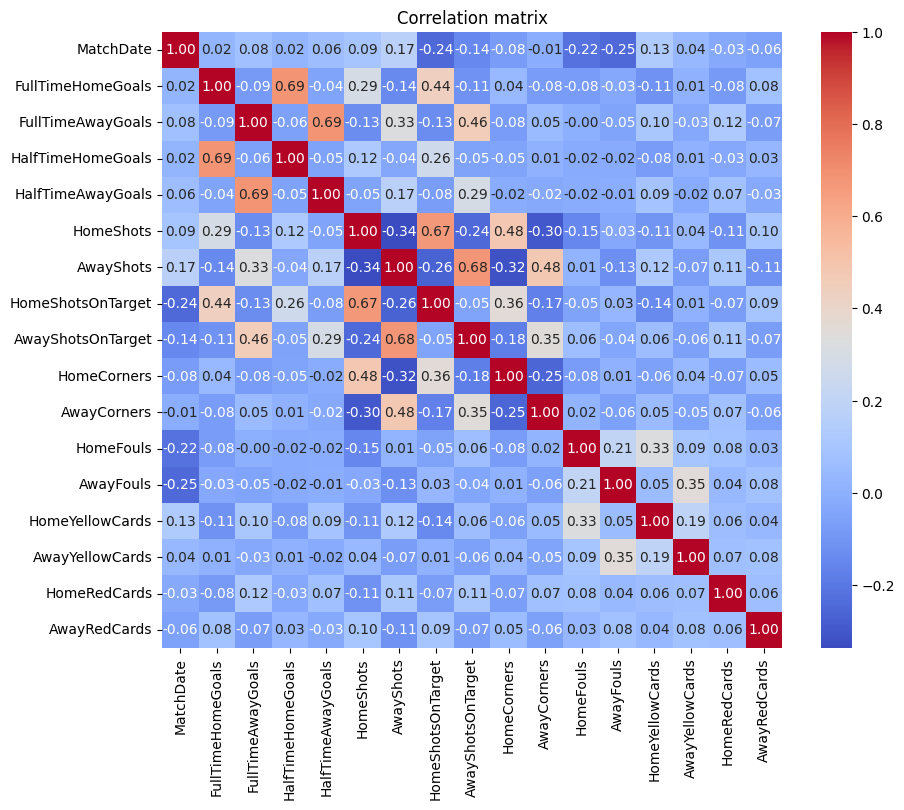

In [8]:
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))
print("\nFirst rows:")
display(df.head())
print("\nSummary statistics:")
display(df.describe(include='all').transpose())

numeric_cols = df.select_dtypes(include='number').columns.tolist()
if numeric_cols:
    print("\nNumeric columns:", numeric_cols)
    corr = df[numeric_cols].corr()
    display(corr)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation matrix")
    plt.show()
else:
    print("No numeric columns found for correlation analysis.")
